# Linear Algebra for Computer Vision

## Course Overview
This notebook covers fundamental linear algebra concepts essential for computer vision, including vectors, matrices, transformations, and their geometric interpretations in images.

**Learning Objectives:**
- Understand vectors, matrices, and their operations
- Learn determinants and eigenvalues with geometric meaning
- Master transformation matrices (rotation, translation, scaling)
- Apply 2D transformations to images using NumPy
- Build image rotation and scaling from scratch

---
# PART 1: MORNING (AM) - VECTORS, MATRICES & LINEAR ALGEBRA FUNDAMENTALS
---

## 1. Introduction & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
np.set_printoptions(precision=3, suppress=True)

print("Libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")

Libraries loaded successfully!
NumPy version: 2.4.0
OpenCV version: 4.13.0


## 2. Vectors: Foundations & Geometric Interpretation

### What is a Vector?
A vector is a mathematical object with both **magnitude** (length) and **direction**. In computer vision:
- Vectors represent directions, displacements, and feature values
- An image pixel location can be represented as a 2D vector (x, y)
- Color information can be a 3D vector (R, G, B)

### Vector Representation:
$$\mathbf{v} = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix}$$

Vector v1: [3 4]
Vector v2: [1 2]
Vector v3: [-2  1]


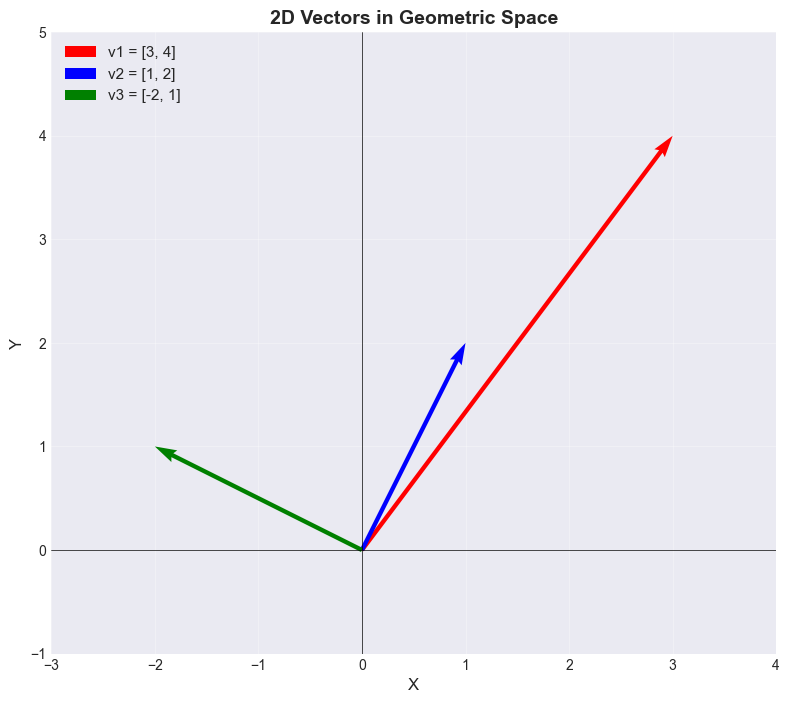

In [2]:
# ============ 2D VECTORS ============
v1 = np.array([3, 4])
v2 = np.array([1, 2])
v3 = np.array([-2, 1])

print("Vector v1:", v1)
print("Vector v2:", v2)
print("Vector v3:", v3)

# Visualize vectors
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Draw vectors as arrows from origin
ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.006, label='v1 = [3, 4]')
ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.006, label='v2 = [1, 2]')
ax.quiver(0, 0, v3[0], v3[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.006, label='v3 = [-2, 1]')

ax.set_xlim(-3, 4)
ax.set_ylim(-1, 5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('2D Vectors in Geometric Space', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

### Vector Operations

In [3]:
# Vector magnitude (length/norm)
magnitude_v1 = np.linalg.norm(v1)
magnitude_v2 = np.linalg.norm(v2)

print("VECTOR MAGNITUDE (L2 Norm)")
print(f"||v1|| = √(3² + 4²) = √25 = {magnitude_v1}")
print(f"||v2|| = √(1² + 2²) = √5 = {magnitude_v2:.3f}")
print()

# Vector addition
v_sum = v1 + v2
print("VECTOR ADDITION")
print(f"v1 + v2 = {v1} + {v2} = {v_sum}")
print()

# Scalar multiplication
scalar = 2
v_scaled = scalar * v1
print("SCALAR MULTIPLICATION")
print(f"{scalar} * v1 = {scalar} * {v1} = {v_scaled}")
print()

# Dot product (Inner product)
dot_product = np.dot(v1, v2)
print("DOT PRODUCT (Inner Product)")
print(f"v1 · v2 = (3)(1) + (4)(2) = {dot_product}")
print()

# Angle between vectors
cos_angle = dot_product / (magnitude_v1 * magnitude_v2)
angle_rad = np.arccos(cos_angle)
angle_deg = np.degrees(angle_rad)
print("ANGLE BETWEEN VECTORS")
print(f"cos(θ) = (v1 · v2) / (||v1|| ||v2||) = {cos_angle:.3f}")
print(f"θ = {angle_deg:.2f}°")
print()

VECTOR MAGNITUDE (L2 Norm)
||v1|| = √(3² + 4²) = √25 = 5.0
||v2|| = √(1² + 2²) = √5 = 2.236

VECTOR ADDITION
v1 + v2 = [3 4] + [1 2] = [4 6]

SCALAR MULTIPLICATION
2 * v1 = 2 * [3 4] = [6 8]

DOT PRODUCT (Inner Product)
v1 · v2 = (3)(1) + (4)(2) = 11

ANGLE BETWEEN VECTORS
cos(θ) = (v1 · v2) / (||v1|| ||v2||) = 0.984
θ = 10.30°



### Visualization: Vector Addition and Dot Product

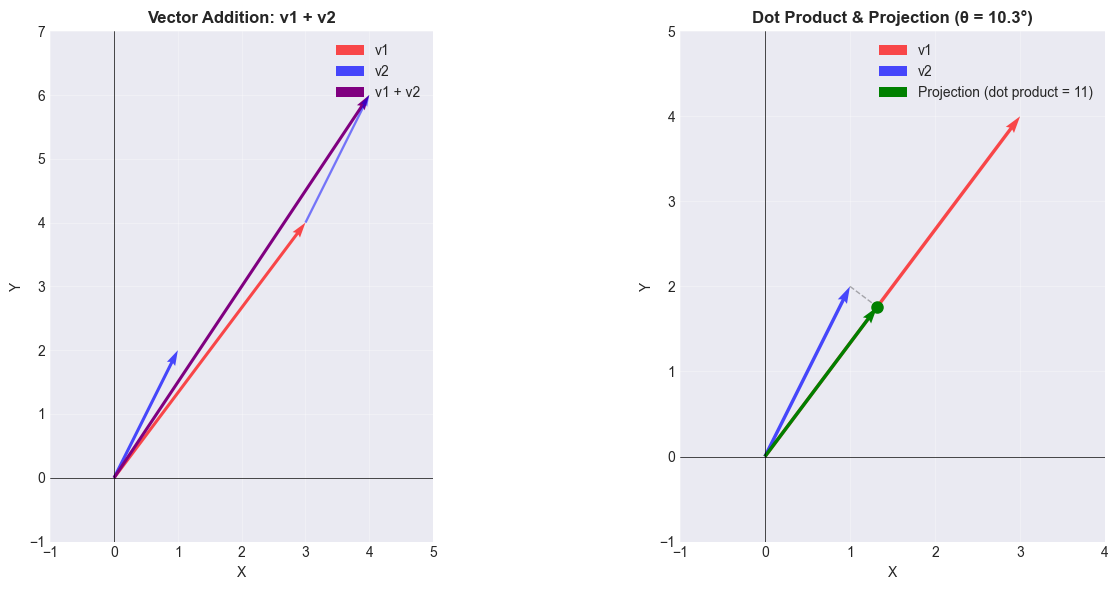

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Vector Addition
ax = axes[0]
ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.008, label='v1', alpha=0.7)
ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.008, label='v2', alpha=0.7)
ax.quiver(0, 0, v_sum[0], v_sum[1], angles='xy', scale_units='xy', scale=1, color='purple', width=0.008, label='v1 + v2', linewidth=2)
ax.quiver(v1[0], v1[1], v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.006, alpha=0.5, linestyle='--')

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 7)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_title('Vector Addition: v1 + v2', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlabel('X')
ax.set_ylabel('Y')

# Dot Product Visualization
ax = axes[1]
ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.008, label='v1', alpha=0.7)
ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.008, label='v2', alpha=0.7)

# Projection of v2 onto v1
v1_unit = v1 / magnitude_v1
proj_length = dot_product / magnitude_v1
projection = proj_length * v1_unit
ax.quiver(0, 0, projection[0], projection[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.008, label=f'Projection (dot product = {dot_product})', linewidth=2)

# Draw projection line
end_point = v2
ax.plot([end_point[0], projection[0]], [end_point[1], projection[1]], 'k--', alpha=0.3, linewidth=1)
ax.plot(projection[0], projection[1], 'go', markersize=8)

ax.set_xlim(-1, 4)
ax.set_ylim(-1, 5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_title(f'Dot Product & Projection (θ = {angle_deg:.1f}°)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.tight_layout()
plt.show()

## 3. Matrices: Fundamentals

### What is a Matrix?
A matrix is a 2D array of numbers arranged in rows and columns. In computer vision:
- **Images** are matrices (2D for grayscale, 3D for color)
- **Transformations** are represented as matrices
- **Covariance matrices** describe feature distributions

### Matrix Representation:
$$\mathbf{A} = \begin{bmatrix} a_{11} & a_{12} & \cdots & a_{1n} \\ a_{21} & a_{22} & \cdots & a_{2n} \\ \vdots & \vdots & \ddots & \vdots \\ a_{m1} & a_{m2} & \cdots & a_{mn} \end{bmatrix}$$

In [5]:
# Create sample matrices
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

B = np.array([
    [2, 0],
    [1, 3],
    [4, 1]
])

print("Matrix A (3x3):")
print(A)
print(f"Shape: {A.shape}")
print()

print("Matrix B (3x2):")
print(B)
print(f"Shape: {B.shape}")
print()

# Matrix properties
print("MATRIX PROPERTIES")
print(f"Transpose of A:\n{A.T}")
print()
print(f"Shape of A.T: {A.T.shape}")

Matrix A (3x3):
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Shape: (3, 3)

Matrix B (3x2):
[[2 0]
 [1 3]
 [4 1]]
Shape: (3, 2)

MATRIX PROPERTIES
Transpose of A:
[[1 4 7]
 [2 5 8]
 [3 6 9]]

Shape of A.T: (3, 3)


## 4. Matrix Multiplication: The Heart of Linear Algebra

### Matrix-Matrix Multiplication
For matrix A (m×n) and B (n×p), the product AB is (m×p) where:

$$(AB)_{ij} = \sum_{k=1}^{n} a_{ik}b_{kj}$$

**Key principle:** The number of columns in A must equal the number of rows in B.

In [6]:
# Matrix-Matrix Multiplication
print("MATRIX-MATRIX MULTIPLICATION")
print(f"A shape: {A.shape}, B shape: {B.shape}")
print(f"A @ B is valid: {A.shape[1]} == {B.shape[0]}")
print()

C = A @ B  # Matrix multiplication
print(f"A @ B (result shape: {C.shape}):")
print(C)
print()

# Matrix-Vector Multiplication
print("MATRIX-VECTOR MULTIPLICATION")
x = np.array([1, 2, 3])
print(f"Vector x: {x}")
print(f"A @ x:")
result = A @ x
print(result)
print()

# Visualize the computation
print("Manual verification of first element:")
print(f"(A @ x)[0] = 1*1 + 2*2 + 3*3 = {1*1 + 2*2 + 3*3}")
print(f"Computed: {result[0]}")

MATRIX-MATRIX MULTIPLICATION
A shape: (3, 3), B shape: (3, 2)
A @ B is valid: 3 == 3

A @ B (result shape: (3, 2)):
[[16  9]
 [37 21]
 [58 33]]

MATRIX-VECTOR MULTIPLICATION
Vector x: [1 2 3]
A @ x:
[14 32 50]

Manual verification of first element:
(A @ x)[0] = 1*1 + 2*2 + 3*3 = 14
Computed: 14


## 5. Determinants: Measuring Volume Change

### What is a Determinant?
The determinant (det(A) or |A|) is a scalar value that:
- **Measures** the volume scaling factor of a transformation
- **Indicates** if a matrix is invertible (det ≠ 0)
- **Shows** orientation (det > 0: same, det < 0: flipped)

### For 2×2 matrix:
$$\det\begin{bmatrix} a & b \\ c & d \end{bmatrix} = ad - bc$$

In [7]:
# Simple 2x2 matrix
M2 = np.array([
    [3, 1],
    [2, 4]
])

det_M2 = np.linalg.det(M2)
print("2×2 Matrix:")
print(M2)
print(f"\nDeterminant = 3*4 - 1*2 = 12 - 2 = {det_M2}")
print()

# 3x3 matrix
det_A = np.linalg.det(A)
print("3×3 Matrix A:")
print(A)
print(f"\nDeterminant: {det_A}")
print("Note: det(A) = 0 means A is singular (not invertible)")
print()

# Another 3x3 matrix with non-zero determinant
M3 = np.array([
    [1, 2, 0],
    [0, 1, 3],
    [2, 0, 1]
])

det_M3 = np.linalg.det(M3)
print("Another 3×3 Matrix:")
print(M3)
print(f"Determinant: {det_M3:.3f}")
print(f"Invertible: {det_M3 != 0}")

2×2 Matrix:
[[3 1]
 [2 4]]

Determinant = 3*4 - 1*2 = 12 - 2 = 10.000000000000002

3×3 Matrix A:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Determinant: 0.0
Note: det(A) = 0 means A is singular (not invertible)

Another 3×3 Matrix:
[[1 2 0]
 [0 1 3]
 [2 0 1]]
Determinant: 13.000
Invertible: True


### Geometric Interpretation of Determinant

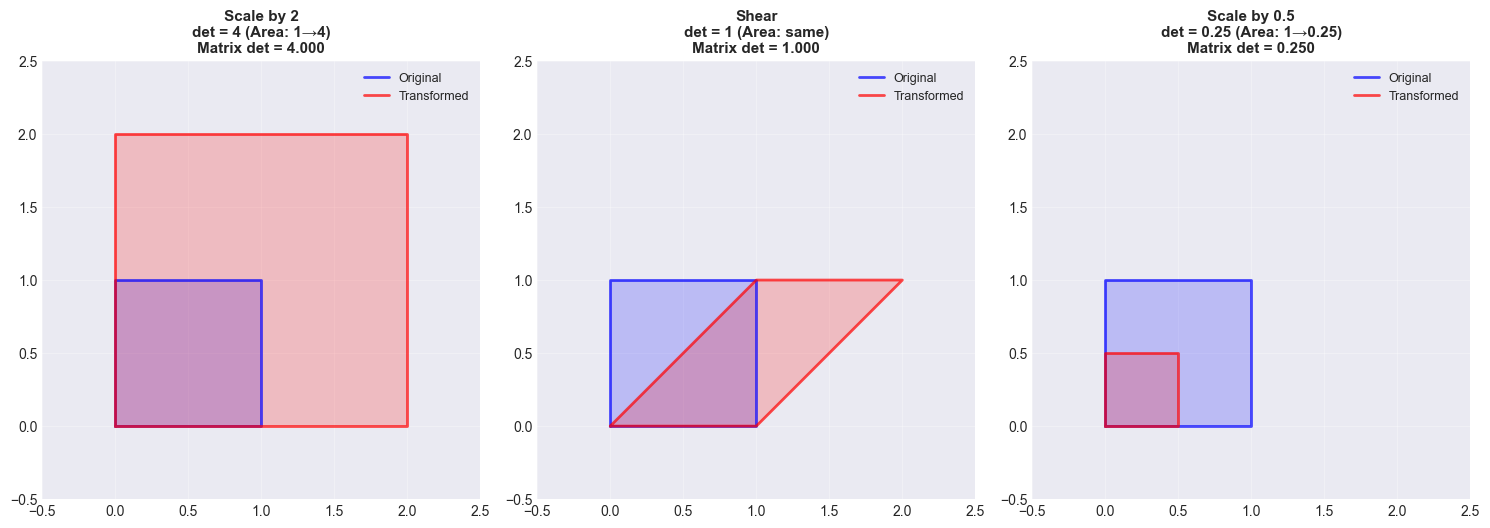

In [8]:
# Show how determinant relates to area scaling
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original unit square
original_points = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T

test_matrices = [
    (np.array([[2, 0], [0, 2]]), "Scale by 2\ndet = 4 (Area: 1→4)"),
    (np.array([[1, 1], [0, 1]]), "Shear\ndet = 1 (Area: same)"),
    (np.array([[0.5, 0], [0, 0.5]]), "Scale by 0.5\ndet = 0.25 (Area: 1→0.25)")
]

for idx, (matrix, title) in enumerate(test_matrices):
    ax = axes[idx]
    
    # Original square
    ax.plot(original_points[0], original_points[1], 'b-', linewidth=2, label='Original', alpha=0.7)
    ax.fill(original_points[0], original_points[1], 'blue', alpha=0.2)
    
    # Transformed square
    transformed = matrix @ original_points
    ax.plot(transformed[0], transformed[1], 'r-', linewidth=2, label='Transformed', alpha=0.7)
    ax.fill(transformed[0], transformed[1], 'red', alpha=0.2)
    
    det = np.linalg.det(matrix)
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 2.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{title}\nMatrix det = {det:.3f}", fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Eigenvalues and Eigenvectors: Axes of Transformation

### Key Concepts
For a matrix A, an **eigenvector** v and **eigenvalue** λ satisfy:

$$A\mathbf{v} = \lambda\mathbf{v}$$

**Geometric meaning:**
- Eigenvectors are directions that don't change during transformation
- Eigenvalues are the scaling factors along those directions
- In images: principal directions of variation in data

In [9]:
# Symmetric matrix (common in CV - covariance matrices)
S = np.array([
    [4, 1],
    [1, 3]
])

print("Symmetric Matrix S:")
print(S)
print()

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(S)

print("Eigenvalues:")
print(eigenvalues)
print()

print("Eigenvectors (columns):")
print(eigenvectors)
print()

# Verify: A*v = λ*v
print("VERIFICATION: S @ v = λ @ v")
for i in range(2):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    left = S @ v
    right = lam * v
    print(f"\nEigenpair {i+1}:")
    print(f"  Eigenvalue λ = {lam:.3f}")
    print(f"  Eigenvector v = {v}")
    print(f"  S @ v = {left}")
    print(f"  λ * v = {right}")
    print(f"  Match: {np.allclose(left, right)}")

Symmetric Matrix S:
[[4 1]
 [1 3]]

Eigenvalues:
[4.618 2.382]

Eigenvectors (columns):
[[ 0.851 -0.526]
 [ 0.526  0.851]]

VERIFICATION: S @ v = λ @ v

Eigenpair 1:
  Eigenvalue λ = 4.618
  Eigenvector v = [0.851 0.526]
  S @ v = [3.928 2.428]
  λ * v = [3.928 2.428]
  Match: True

Eigenpair 2:
  Eigenvalue λ = 2.382
  Eigenvector v = [-0.526  0.851]
  S @ v = [-1.252  2.026]
  λ * v = [-1.252  2.026]
  Match: True


### Visualizing Eigenvectors and Eigenvalues

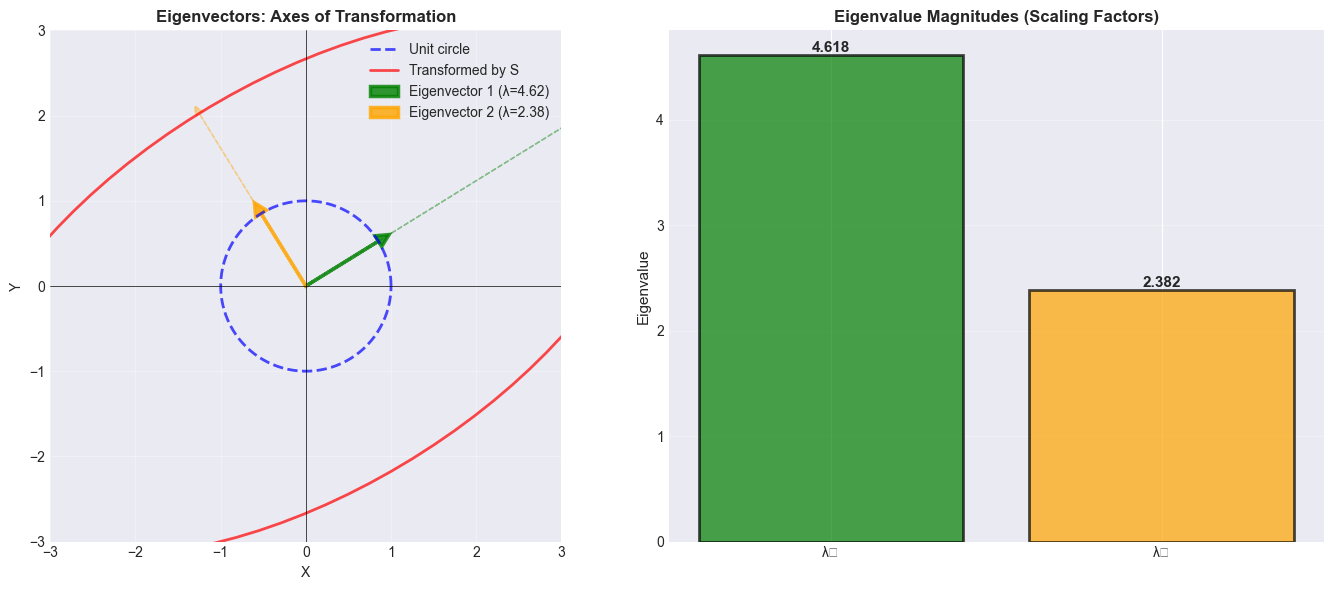

In [10]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Eigenvectors and transformation
ax = axes[0]
circle_points = np.array([np.cos(np.linspace(0, 2*np.pi, 100)),
                           np.sin(np.linspace(0, 2*np.pi, 100))])
transformed_circle = S @ circle_points

ax.plot(circle_points[0], circle_points[1], 'b--', linewidth=2, label='Unit circle', alpha=0.7)
ax.plot(transformed_circle[0], transformed_circle[1], 'r-', linewidth=2, label='Transformed by S', alpha=0.7)

# Plot eigenvectors with their eigenvalue scales
colors = ['green', 'orange']
for i in range(2):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    ax.arrow(0, 0, v[0], v[1], head_width=0.15, head_length=0.15, 
             fc=colors[i], ec=colors[i], linewidth=2.5, label=f'Eigenvector {i+1} (λ={lam:.2f})', alpha=0.8)
    ax.arrow(0, 0, lam*v[0], lam*v[1], head_width=0.1, head_length=0.1, 
             fc=colors[i], ec=colors[i], linewidth=1, alpha=0.4, linestyle='--')

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_title('Eigenvectors: Axes of Transformation', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlabel('X')
ax.set_ylabel('Y')

# Right plot: Eigenvalue magnitude
ax = axes[1]
bars = ax.bar(['λ₁', 'λ₂'], eigenvalues, color=['green', 'orange'], alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Eigenvalue', fontsize=11)
ax.set_title('Eigenvalue Magnitudes (Scaling Factors)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, eigenvalues):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Geometric Interpretation: How Linear Algebra Applies to Images

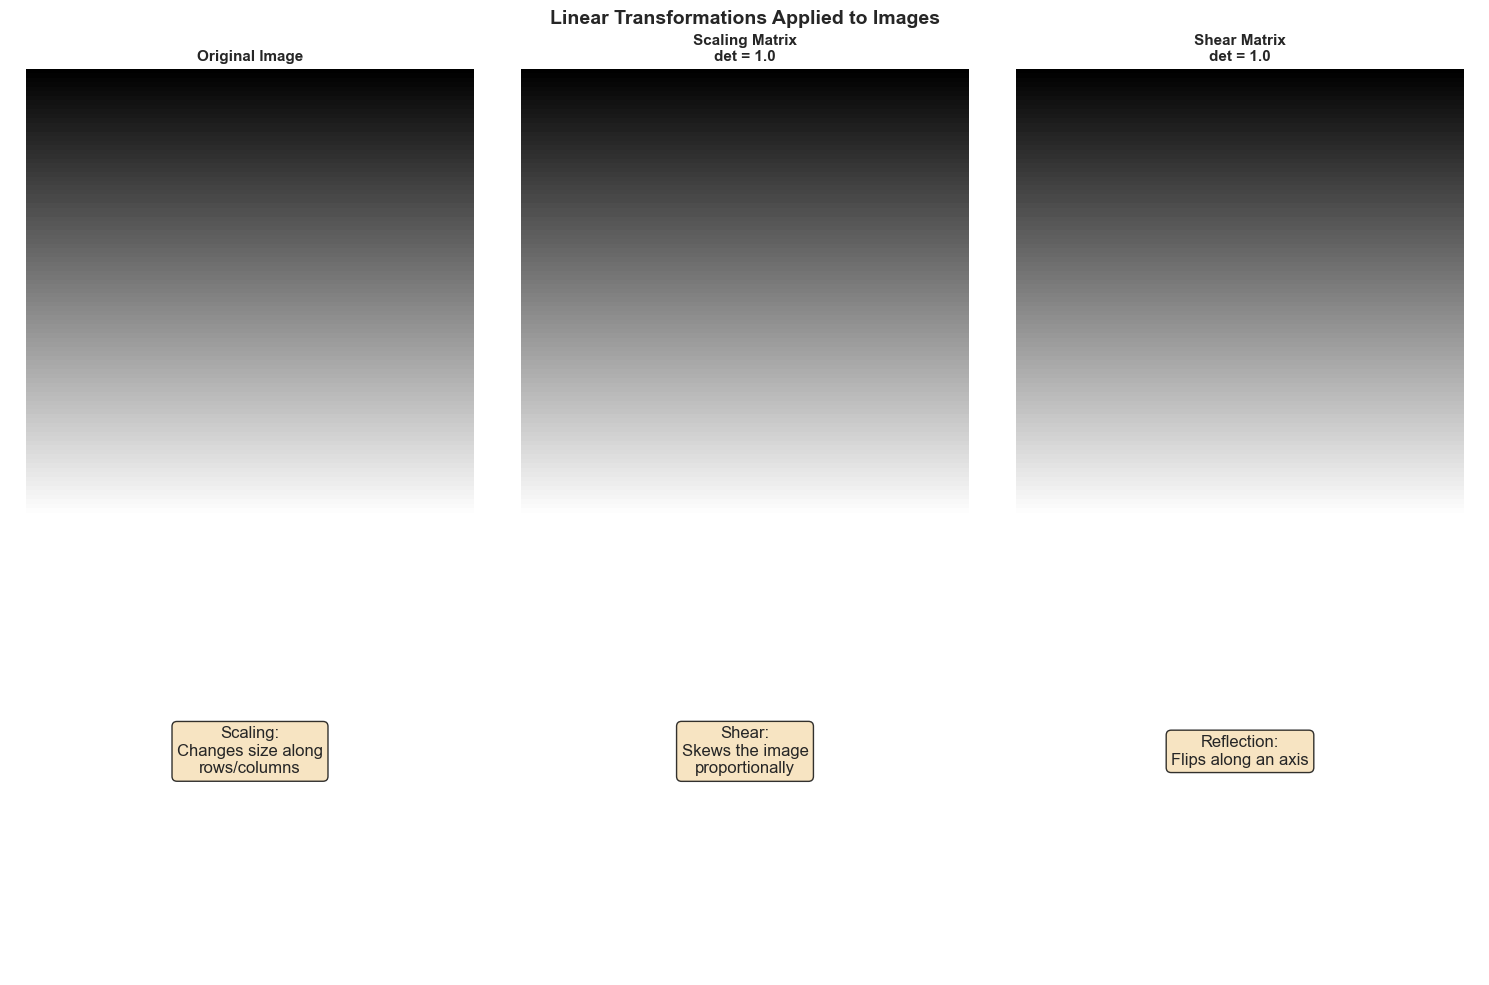


Key Insights:
1. Images are matrices of pixel intensities
2. Transformations change image geometry and appearance
3. Determinant tells us about area/volume changes
4. Eigenvalues/eigenvectors reveal principal directions of variation


In [11]:
# Create a simple image (gradient)
image = np.zeros((100, 100))
for i in range(100):
    image[i, :] = i

# Apply different transformations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

# Scaling transformation
scale_matrix = np.array([[2, 0], [0, 0.5]])  # Scale x by 2, y by 0.5
axes[0, 1].imshow(image, cmap='gray')
axes[0, 1].set_title(f'Scaling Matrix\ndet = {np.linalg.det(scale_matrix):.1f}', fontsize=11, fontweight='bold')
axes[0, 1].axis('off')

# Shear transformation
shear_matrix = np.array([[1, 0.5], [0, 1]])  # Shear in x
axes[0, 2].imshow(image, cmap='gray')
axes[0, 2].set_title(f'Shear Matrix\ndet = {np.linalg.det(shear_matrix):.1f}', fontsize=11, fontweight='bold')
axes[0, 2].axis('off')

# Explanation of transformations
text_explanations = [
    "Scaling:\nChanges size along\nrows/columns",
    "Shear:\nSkews the image\nproportionally",
    "Reflection:\nFlips along an axis"
]

for i in range(3):
    ax = axes[1, i]
    ax.text(0.5, 0.5, text_explanations[i], ha='center', va='center', 
            fontsize=12, transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax.axis('off')

plt.suptitle('Linear Transformations Applied to Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("1. Images are matrices of pixel intensities")
print("2. Transformations change image geometry and appearance")
print("3. Determinant tells us about area/volume changes")
print("4. Eigenvalues/eigenvectors reveal principal directions of variation")

---
# PART 2: AFTERNOON (PM) - TRANSFORMATION MATRICES & APPLICATIONS
---

## 8. Introduction to 2D Transformation Matrices

### Core Concept
A 2D point (x, y) can be transformed using:

$$\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} a & b \\ c & d \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix}$$

For homogeneous coordinates (adding translation):

$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} a & b & t_x \\ c & d & t_y \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$

## 9. Rotation Transformation

In [12]:
print("ROTATION TRANSFORMATION")
print("="*50)
print()

# Rotation matrix for angle θ (counterclockwise)
# R(θ) = [[cos(θ), -sin(θ)],
#         [sin(θ),  cos(θ)]]

def rotation_matrix_2d(angle_degrees):
    """Create a 2D rotation matrix
    
    Parameters:
    -----------
    angle_degrees : float
        Rotation angle in degrees (counterclockwise)
    
    Returns:
    --------
    rotation_matrix : ndarray of shape (2, 2)
    """
    angle_rad = np.radians(angle_degrees)
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)
    
    R = np.array([
        [cos_a, -sin_a],
        [sin_a,  cos_a]
    ])
    
    return R

# Example: Rotate by 45 degrees
angle = 45
R45 = rotation_matrix_2d(angle)

print(f"Rotation matrix for {angle}°:")
print(R45)
print()

# Test on a point
point = np.array([1, 0])
rotated_point = R45 @ point

print(f"Original point: {point}")
print(f"Rotated point (45°): {rotated_point}")
print(f"Expected: [√2/2, √2/2] ≈ [0.707, 0.707]")
print()

# Properties of rotation matrix
print("PROPERTIES OF ROTATION MATRIX:")
print(f"Determinant: {np.linalg.det(R45):.6f} (should be 1 - preserves area)")
print(f"Is orthogonal (R^T @ R = I): {np.allclose(R45.T @ R45, np.eye(2))}")
print(f"Inverse equals transpose: {np.allclose(np.linalg.inv(R45), R45.T)}")

ROTATION TRANSFORMATION

Rotation matrix for 45°:
[[ 0.707 -0.707]
 [ 0.707  0.707]]

Original point: [1 0]
Rotated point (45°): [0.707 0.707]
Expected: [√2/2, √2/2] ≈ [0.707, 0.707]

PROPERTIES OF ROTATION MATRIX:
Determinant: 1.000000 (should be 1 - preserves area)
Is orthogonal (R^T @ R = I): True
Inverse equals transpose: True


## 10. Translation Transformation

In [13]:
print("TRANSLATION TRANSFORMATION")
print("="*50)
print()

# Note: Translation cannot be done with 2x2 matrix
# We need homogeneous coordinates (3x3 for 2D)

def translation_matrix_homogeneous(tx, ty):
    """Create a 3x3 translation matrix for homogeneous coordinates
    
    Parameters:
    -----------
    tx, ty : float
        Translation in x and y directions
    
    Returns:
    --------
    T : ndarray of shape (3, 3)
    """
    T = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])
    return T

# Example: Translate by (3, 2)
tx, ty = 3, 2
T = translation_matrix_homogeneous(tx, ty)

print(f"Translation matrix T({tx}, {ty}):")
print(T)
print()

# Test on a point (in homogeneous coordinates)
point_homo = np.array([1, 1, 1])  # (x=1, y=1) in homogeneous coords
translated_point = T @ point_homo

print(f"Original point: ({point_homo[0]}, {point_homo[1]})")
print(f"Translated point: ({translated_point[0]}, {translated_point[1]})")
print(f"Expected: ({1+tx}, {1+ty})")
print()

print("Why Homogeneous Coordinates?")
print("- Simple 2x2 matrix cannot represent translation")
print("- By adding dimension (x,y,1), we can use 3x3 matrix")
print("- Allows combining rotation, translation, scaling in single matrix")

TRANSLATION TRANSFORMATION

Translation matrix T(3, 2):
[[1 0 3]
 [0 1 2]
 [0 0 1]]

Original point: (1, 1)
Translated point: (4, 3)
Expected: (4, 3)

Why Homogeneous Coordinates?
- Simple 2x2 matrix cannot represent translation
- By adding dimension (x,y,1), we can use 3x3 matrix
- Allows combining rotation, translation, scaling in single matrix


## 11. Scaling Transformation

In [14]:
print("SCALING TRANSFORMATION")
print("="*50)
print()

def scaling_matrix_2d(sx, sy):
    """Create a 2D scaling matrix
    
    Parameters:
    -----------
    sx, sy : float
        Scale factors for x and y
    
    Returns:
    --------
    S : ndarray of shape (2, 2)
    """
    S = np.array([
        [sx, 0],
        [0, sy]
    ])
    return S

def scaling_matrix_homogeneous(sx, sy):
    """Create a 3x3 scaling matrix for homogeneous coordinates"""
    S = np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ])
    return S

# Example: Scale by (2, 0.5)
sx, sy = 2, 0.5
S = scaling_matrix_2d(sx, sy)

print(f"Scaling matrix S({sx}, {sy}):")
print(S)
print()

# Test on a point
point = np.array([2, 4])
scaled_point = S @ point

print(f"Original point: {point}")
print(f"Scaled point: {scaled_point}")
print(f"Expected: [{2*sx}, {4*sy}]")
print()

# Properties
print("PROPERTIES OF SCALING MATRIX:")
print(f"Determinant: {np.linalg.det(S):.3f} (area scaled by {sx}×{sy} = {sx*sy})")
print(f"Area scaling factor: {sx * sy}")

SCALING TRANSFORMATION

Scaling matrix S(2, 0.5):
[[2.  0. ]
 [0.  0.5]]

Original point: [2 4]
Scaled point: [4. 2.]
Expected: [4, 2.0]

PROPERTIES OF SCALING MATRIX:
Determinant: 1.000 (area scaled by 2×0.5 = 1.0)
Area scaling factor: 1.0


## 12. Combining Transformations

In [15]:
print("COMBINING TRANSFORMATIONS")
print("="*50)
print()

# Create homogeneous versions of all matrices
angle = 30  # degrees
R = np.array([
    [np.cos(np.radians(angle)), -np.sin(np.radians(angle)), 0],
    [np.sin(np.radians(angle)),  np.cos(np.radians(angle)), 0],
    [0, 0, 1]
])

S_homo = scaling_matrix_homogeneous(1.5, 1.5)
T = translation_matrix_homogeneous(2, 3)

print("Individual Transformations:")
print(f"Rotation (30°): \n{R[:2, :2]}")
print()
print(f"Scaling (1.5x): \n{S_homo[:2, :2]}")
print()
print(f"Translation (2, 3): \n{T[:2, :]}")
print()

# Combine: Translate after rotating and scaling
# Order matters: T @ S @ R means first rotate, then scale, then translate
combined = T @ S_homo @ R

print("Combined Transformation (T @ S @ R):")
print(combined)
print()

# Test on a point
point = np.array([1, 0, 1])  # homogeneous
result = combined @ point

print(f"Applying combined transform to point (1, 0):")
print(f"Result: ({result[0]:.3f}, {result[1]:.3f})")
print()
print("Key Point: Matrix multiplication is NOT commutative!")
print(f"Rotating then translating ≠ Translating then rotating")

COMBINING TRANSFORMATIONS

Individual Transformations:
Rotation (30°): 
[[ 0.866 -0.5  ]
 [ 0.5    0.866]]

Scaling (1.5x): 
[[1.5 0. ]
 [0.  1.5]]

Translation (2, 3): 
[[1 0 2]
 [0 1 3]]

Combined Transformation (T @ S @ R):
[[ 1.299 -0.75   2.   ]
 [ 0.75   1.299  3.   ]
 [ 0.     0.     1.   ]]

Applying combined transform to point (1, 0):
Result: (3.299, 3.750)

Key Point: Matrix multiplication is NOT commutative!
Rotating then translating ≠ Translating then rotating


### Visualization: Combining Transformations

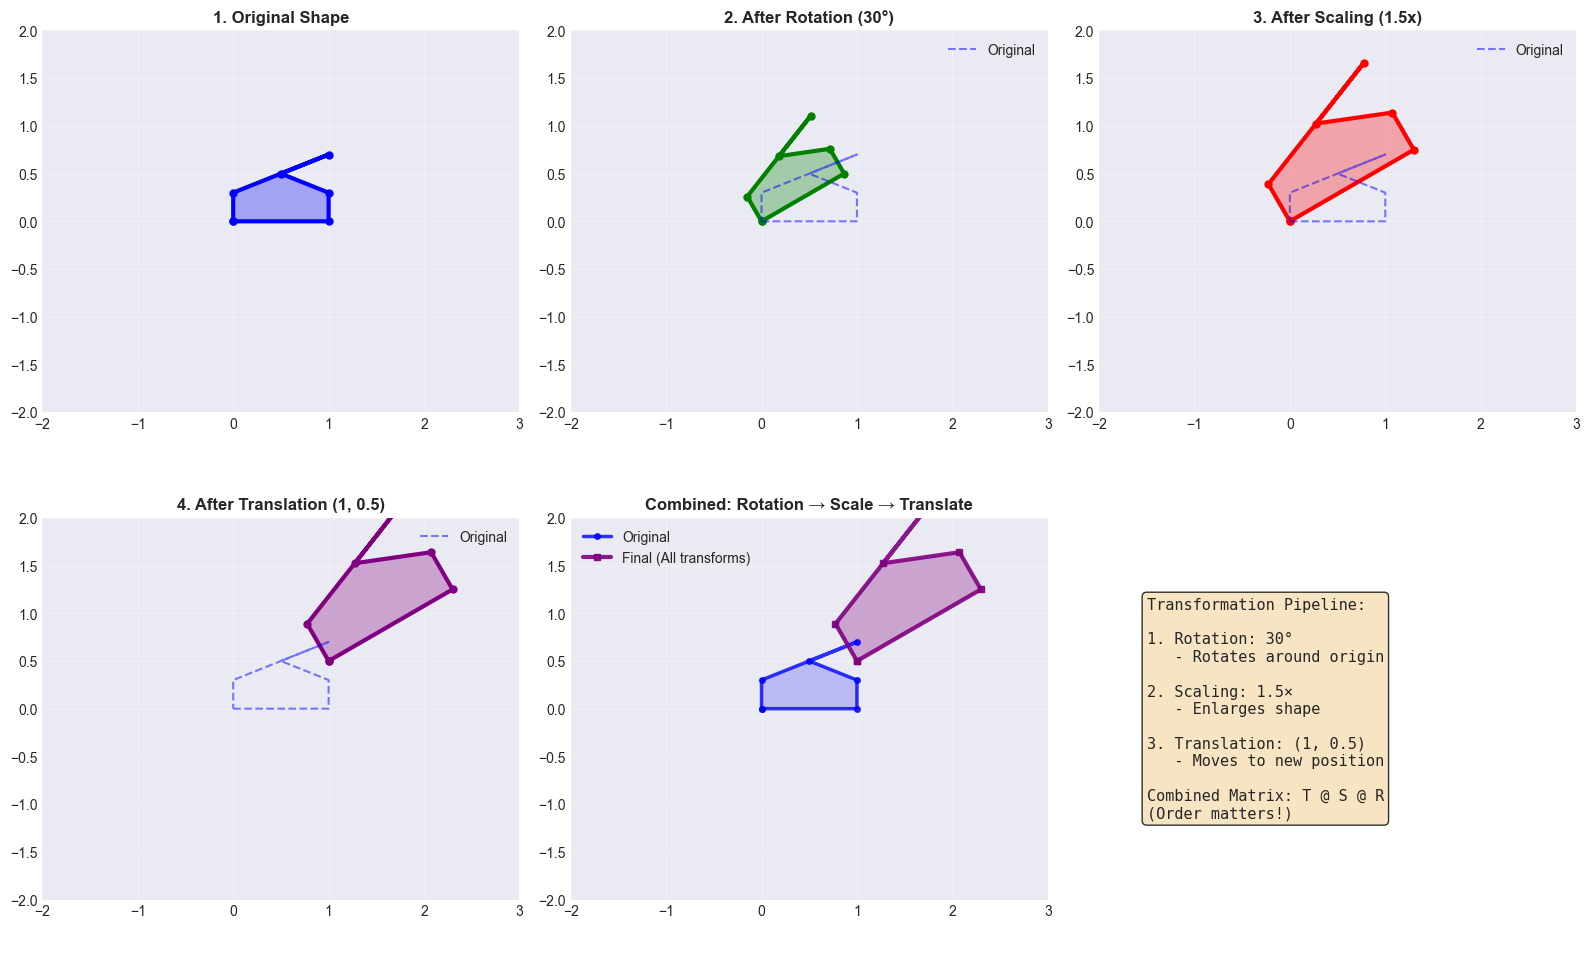

In [16]:
# Create a shape (arrow) to visualize transformations
arrow = np.array([[0, 1, 1, 0.5, 1, 0, 0],
                   [0, 0, 0.3, 0.5, 0.7, 0.3, 0],
                   [1, 1, 1, 1, 1, 1, 1]])  # homogeneous

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Step 1: Original
ax = axes[0, 0]
ax.plot(arrow[0], arrow[1], 'b-', linewidth=3, marker='o', markersize=5)
ax.fill(arrow[0], arrow[1], 'blue', alpha=0.3)
ax.set_xlim(-2, 3)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('1. Original Shape', fontsize=12, fontweight='bold')
current = arrow.copy()

# Step 2: After Rotation
ax = axes[0, 1]
angle = 30
R_homo = np.eye(3)
c, s = np.cos(np.radians(angle)), np.sin(np.radians(angle))
R_homo[:2, :2] = [[c, -s], [s, c]]
current = R_homo @ current
ax.plot(current[0], current[1], 'g-', linewidth=3, marker='o', markersize=5)
ax.fill(current[0], current[1], 'green', alpha=0.3)
ax.plot(arrow[0], arrow[1], 'b--', linewidth=1.5, alpha=0.5, label='Original')
ax.set_xlim(-2, 3)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title(f'2. After Rotation ({angle}°)', fontsize=12, fontweight='bold')
ax.legend()

# Step 3: After Scaling
ax = axes[0, 2]
S_homo = np.eye(3)
S_homo[0, 0] = 1.5
S_homo[1, 1] = 1.5
current = S_homo @ current
ax.plot(current[0], current[1], 'r-', linewidth=3, marker='o', markersize=5)
ax.fill(current[0], current[1], 'red', alpha=0.3)
ax.plot(arrow[0], arrow[1], 'b--', linewidth=1.5, alpha=0.5, label='Original')
ax.set_xlim(-2, 3)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('3. After Scaling (1.5x)', fontsize=12, fontweight='bold')
ax.legend()

# Step 4: After Translation
ax = axes[1, 0]
T = translation_matrix_homogeneous(1, 0.5)
final = T @ current
ax.plot(final[0], final[1], 'purple', linewidth=3, marker='o', markersize=5)
ax.fill(final[0], final[1], 'purple', alpha=0.3)
ax.plot(arrow[0], arrow[1], 'b--', linewidth=1.5, alpha=0.5, label='Original')
ax.set_xlim(-2, 3)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('4. After Translation (1, 0.5)', fontsize=12, fontweight='bold')
ax.legend()

# All steps combined
ax = axes[1, 1]
ax.plot(arrow[0], arrow[1], 'b-', linewidth=2.5, marker='o', markersize=4, label='Original', alpha=0.8)
ax.fill(arrow[0], arrow[1], 'blue', alpha=0.2)
ax.plot(final[0], final[1], 'purple', linewidth=3, marker='s', markersize=5, label='Final (All transforms)', alpha=0.9)
ax.fill(final[0], final[1], 'purple', alpha=0.3)
ax.set_xlim(-2, 3)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('Combined: Rotation → Scale → Translate', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

# Summary text
ax = axes[1, 2]
ax.axis('off')
summary_text = """Transformation Pipeline:

1. Rotation: 30°
   - Rotates around origin
   
2. Scaling: 1.5×
   - Enlarges shape
   
3. Translation: (1, 0.5)
   - Moves to new position
   
Combined Matrix: T @ S @ R
(Order matters!)"""
ax.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
        family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

---
# PART 3: PRACTICAL APPLICATION - IMAGE TRANSFORMATION
---

## 13. Building Image Transformation Functions from Scratch

In [17]:
def rotate_image_from_scratch(image, angle_degrees, center=None):
    """
    Rotate an image by a given angle using transformation matrices.
    
    Parameters:
    -----------
    image : ndarray of shape (H, W) or (H, W, C)
        Input image
    angle_degrees : float
        Rotation angle in degrees (counterclockwise)
    center : tuple of (x, y), optional
        Center of rotation. If None, uses image center.
    
    Returns:
    --------
    rotated : ndarray
        Rotated image
    """
    h, w = image.shape[:2]
    
    # Default center is image center
    if center is None:
        center = (w / 2, h / 2)
    
    cx, cy = center
    
    # Convert angle to radians
    angle_rad = np.radians(angle_degrees)
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)
    
    # Rotation matrix
    R = np.array([
        [cos_a, -sin_a, -cx*cos_a + cy*sin_a + cx],
        [sin_a,  cos_a, -cx*sin_a - cy*cos_a + cy]
    ])
    
    # Use cv2.warpAffine to apply transformation
    rotated = cv2.warpAffine(image, R, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=255)
    
    return rotated, R


def scale_image_from_scratch(image, scale_x, scale_y):
    """
    Scale an image using transformation matrices.
    
    Parameters:
    -----------
    image : ndarray of shape (H, W) or (H, W, C)
        Input image
    scale_x, scale_y : float
        Scale factors for x and y directions
    
    Returns:
    --------
    scaled : ndarray
        Scaled image
    """
    h, w = image.shape[:2]
    
    # New dimensions
    new_w = int(w * scale_x)
    new_h = int(h * scale_y)
    
    # Scaling matrix (inverse for image warping)
    S = np.array([
        [1/scale_x, 0, 0],
        [0, 1/scale_y, 0]
    ])
    
    scaled = cv2.warpAffine(image, S, (new_w, new_h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=255)
    
    return scaled, S


def combined_transform_image(image, angle_degrees, scale_x, scale_y, translate_x, translate_y):
    """
    Apply combined transformation (rotation, scaling, translation) to image.
    
    Parameters:
    -----------
    image : ndarray
        Input image
    angle_degrees : float
        Rotation angle
    scale_x, scale_y : float
        Scale factors
    translate_x, translate_y : float
        Translation amounts
    
    Returns:
    --------
    transformed : ndarray
        Transformed image
    M : ndarray of shape (2, 3)
        Combined transformation matrix
    """
    h, w = image.shape[:2]
    cx, cy = w / 2, h / 2
    
    angle_rad = np.radians(angle_degrees)
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)
    
    # Combined transformation matrix
    # First translate to origin, then rotate+scale, then translate back+apply translation
    M = np.array([
        [scale_x * cos_a, -scale_y * sin_a, -cx*scale_x*cos_a + cy*scale_y*sin_a + cx + translate_x],
        [scale_x * sin_a,  scale_y * cos_a, -cx*scale_x*sin_a - cy*scale_y*cos_a + cy + translate_y]
    ])
    
    transformed = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=255)
    
    return transformed, M

print("Functions created successfully!")
print("\nFunctions available:")
print("1. rotate_image_from_scratch(image, angle_degrees, center)")
print("2. scale_image_from_scratch(image, scale_x, scale_y)")
print("3. combined_transform_image(image, angle, scale_x, scale_y, tx, ty)")

Functions created successfully!

Functions available:
1. rotate_image_from_scratch(image, angle_degrees, center)
2. scale_image_from_scratch(image, scale_x, scale_y)
3. combined_transform_image(image, angle, scale_x, scale_y, tx, ty)


## 14. Create a Test Image

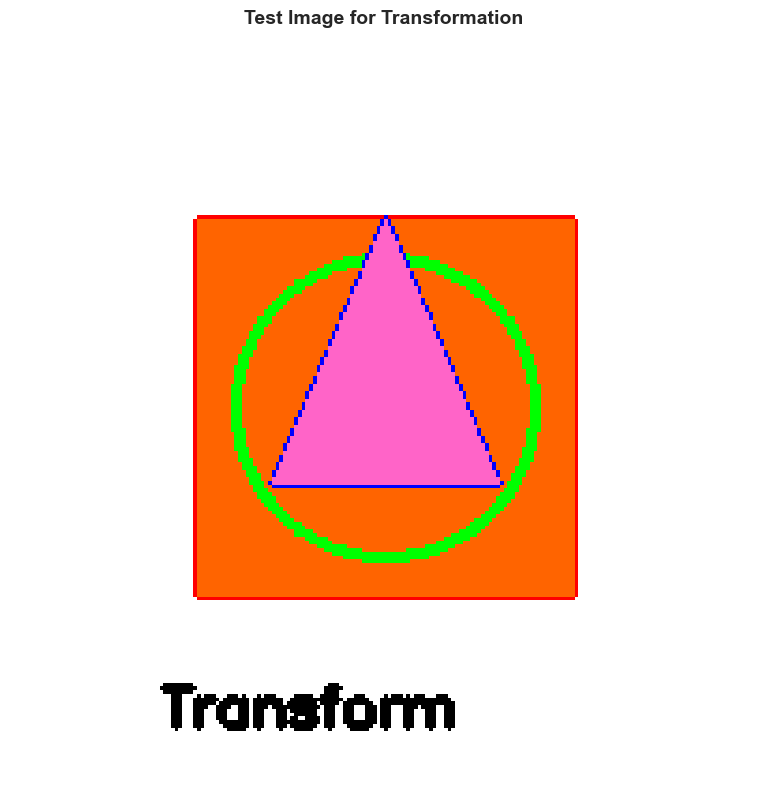

Test image created with shape: (200, 200, 3)


In [18]:
# Create a test image with geometric shapes
test_image = np.ones((200, 200, 3), dtype=np.uint8) * 255  # White background

# Draw a square
cv2.rectangle(test_image, (50, 50), (150, 150), (0, 0, 255), 2)  # Red square
cv2.rectangle(test_image, (50, 50), (150, 150), (0, 100, 255), -1)  # Filled

# Draw a circle
cv2.circle(test_image, (100, 100), 40, (0, 255, 0), 2)  # Green circle

# Draw a triangle
pts = np.array([[100, 50], [130, 120], [70, 120]], np.int32)
cv2.polylines(test_image, [pts], True, (255, 0, 0), 2)  # Blue triangle
cv2.fillPoly(test_image, [pts], (200, 100, 255))  # Pink fill

# Add text
cv2.putText(test_image, 'Transform', (40, 185), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
plt.title('Test Image for Transformation', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Test image created with shape: {test_image.shape}")

## 15. Rotation Demonstration

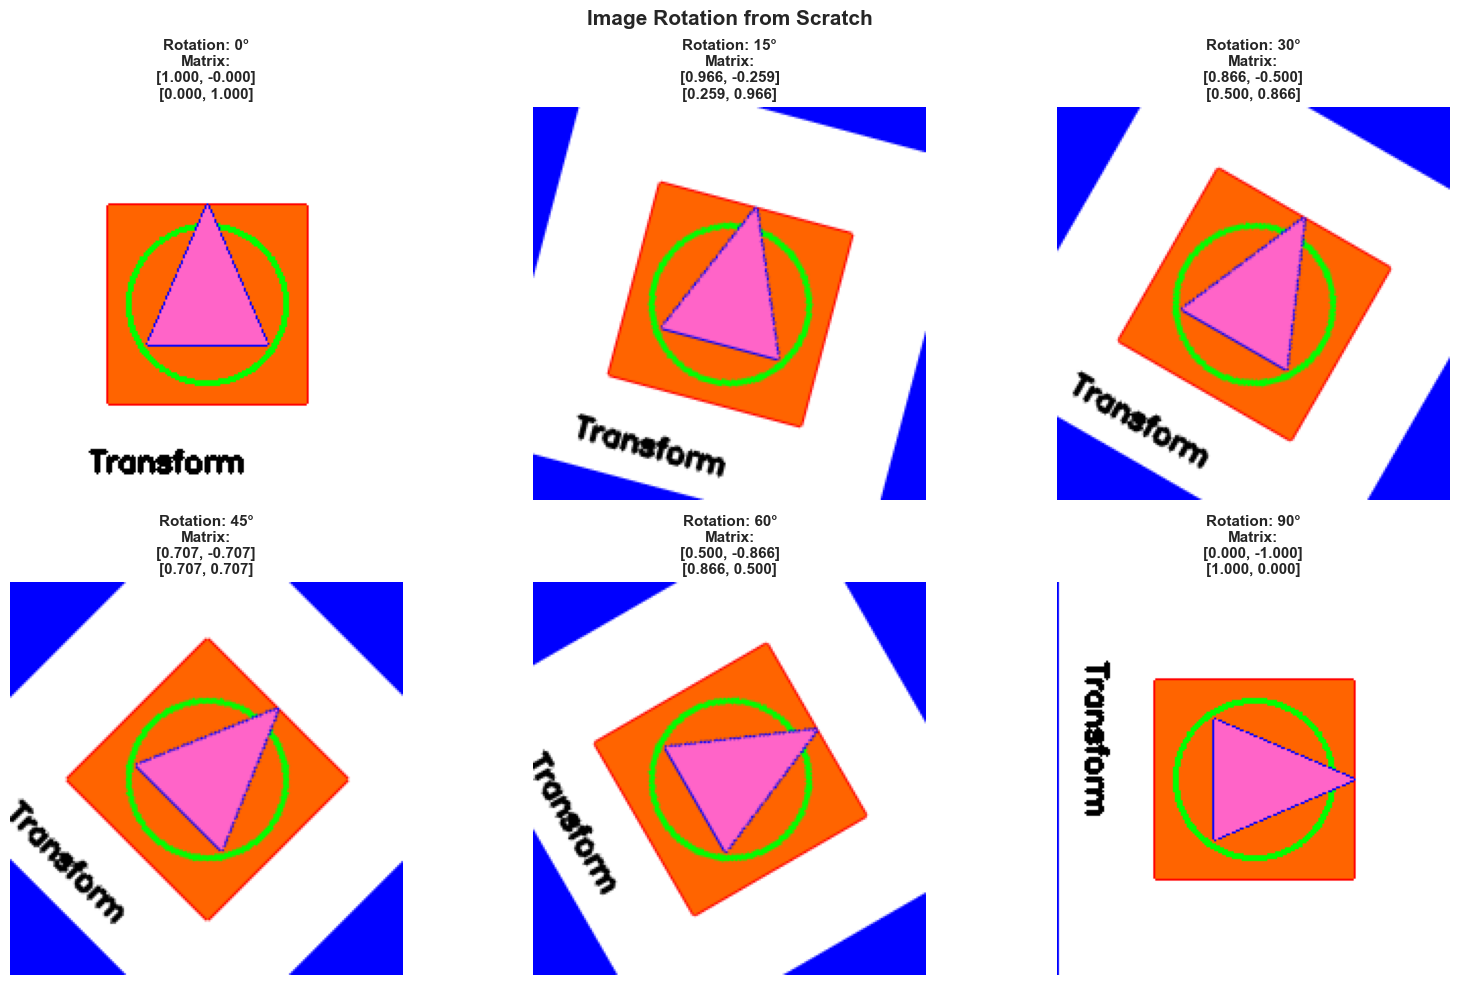

Rotation matrix for 30°:
[[  0.866  -0.5    63.397]
 [  0.5     0.866 -36.603]]


In [19]:
# Test different rotation angles
angles = [0, 15, 30, 45, 60, 90]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, angle in enumerate(angles):
    rotated, R = rotate_image_from_scratch(test_image, angle)
    
    axes[idx].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f'Rotation: {angle}°\n'
                       f'Matrix:\n[{R[0,0]:.3f}, {R[0,1]:.3f}]\n[{R[1,0]:.3f}, {R[1,1]:.3f}]',
                       fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Image Rotation from Scratch', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Rotation matrix for 30°:")
rotated_30, R30 = rotate_image_from_scratch(test_image, 30)
print(R30)

## 16. Scaling Demonstration

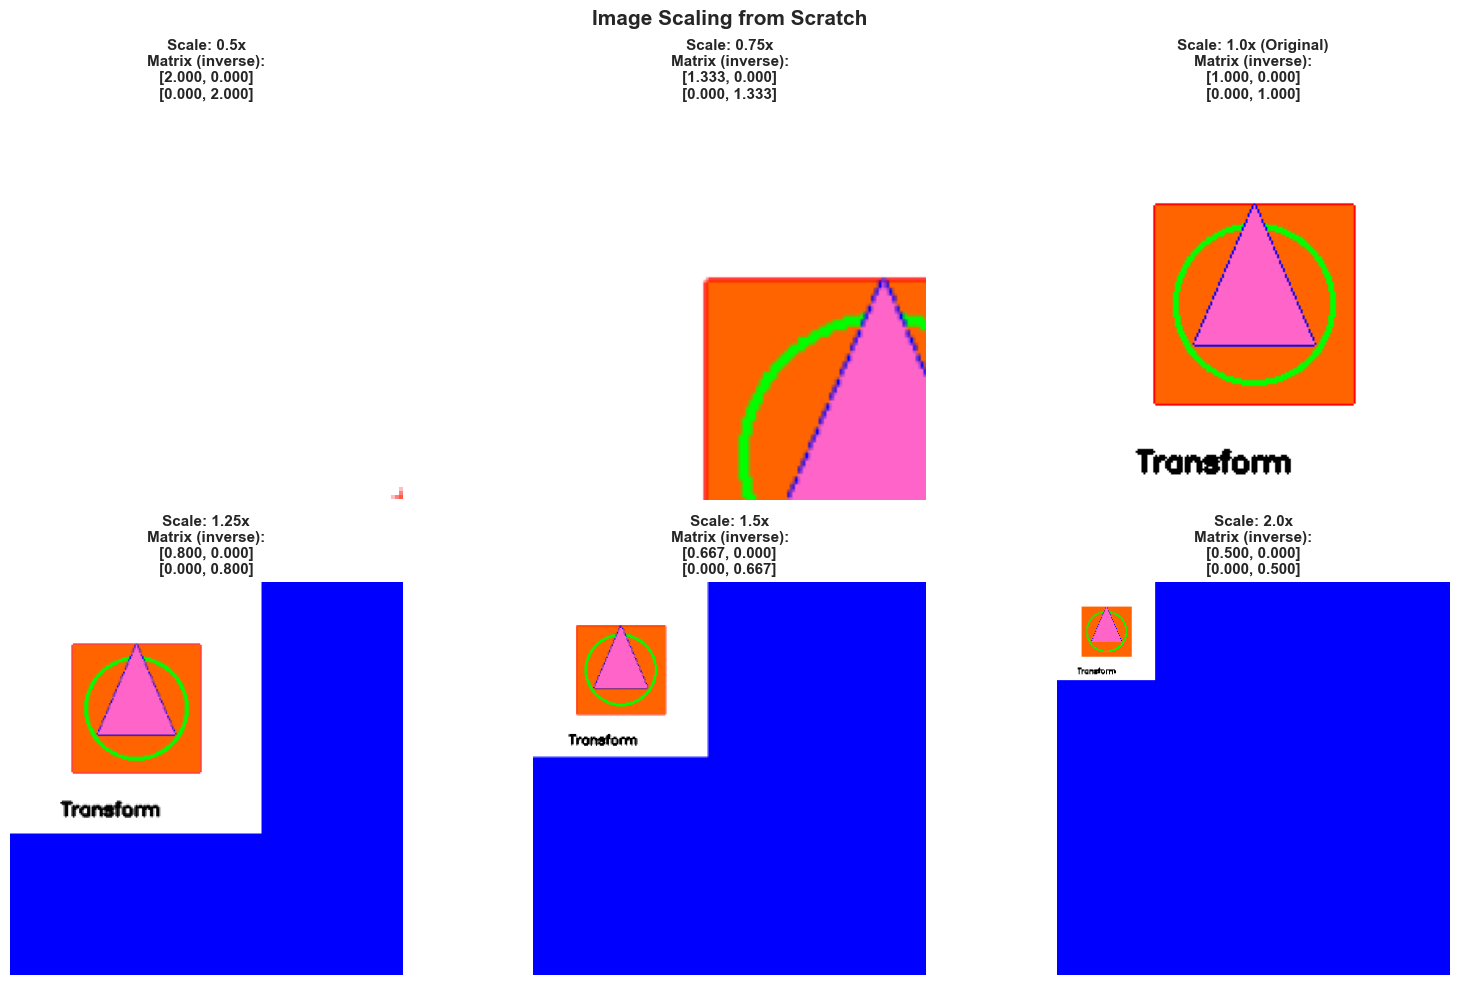

Scaling factor impact:
0.5x            -> Size: 100x100
0.75x           -> Size: 150x150
1.0x (Original) -> Size: 200x200
1.25x           -> Size: 250x250
1.5x            -> Size: 300x300
2.0x            -> Size: 400x400


In [20]:
# Test different scaling factors
scales = [(0.5, 0.5), (0.75, 0.75), (1.0, 1.0), (1.25, 1.25), (1.5, 1.5), (2.0, 2.0)]
scale_labels = ['0.5x', '0.75x', '1.0x (Original)', '1.25x', '1.5x', '2.0x']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, ((sx, sy), label) in enumerate(zip(scales, scale_labels)):
    scaled, S = scale_image_from_scratch(test_image, sx, sy)
    
    axes[idx].imshow(cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f'Scale: {label}\n'
                       f'Matrix (inverse):\n[{S[0,0]:.3f}, {S[0,1]:.3f}]\n[{S[1,0]:.3f}, {S[1,1]:.3f}]',
                       fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Image Scaling from Scratch', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("Scaling factor impact:")
for (sx, sy), label in zip(scales, scale_labels):
    new_w = int(200 * sx)
    new_h = int(200 * sy)
    print(f"{label:15} -> Size: {new_w}x{new_h}")

## 17. Combined Transformation Demonstration

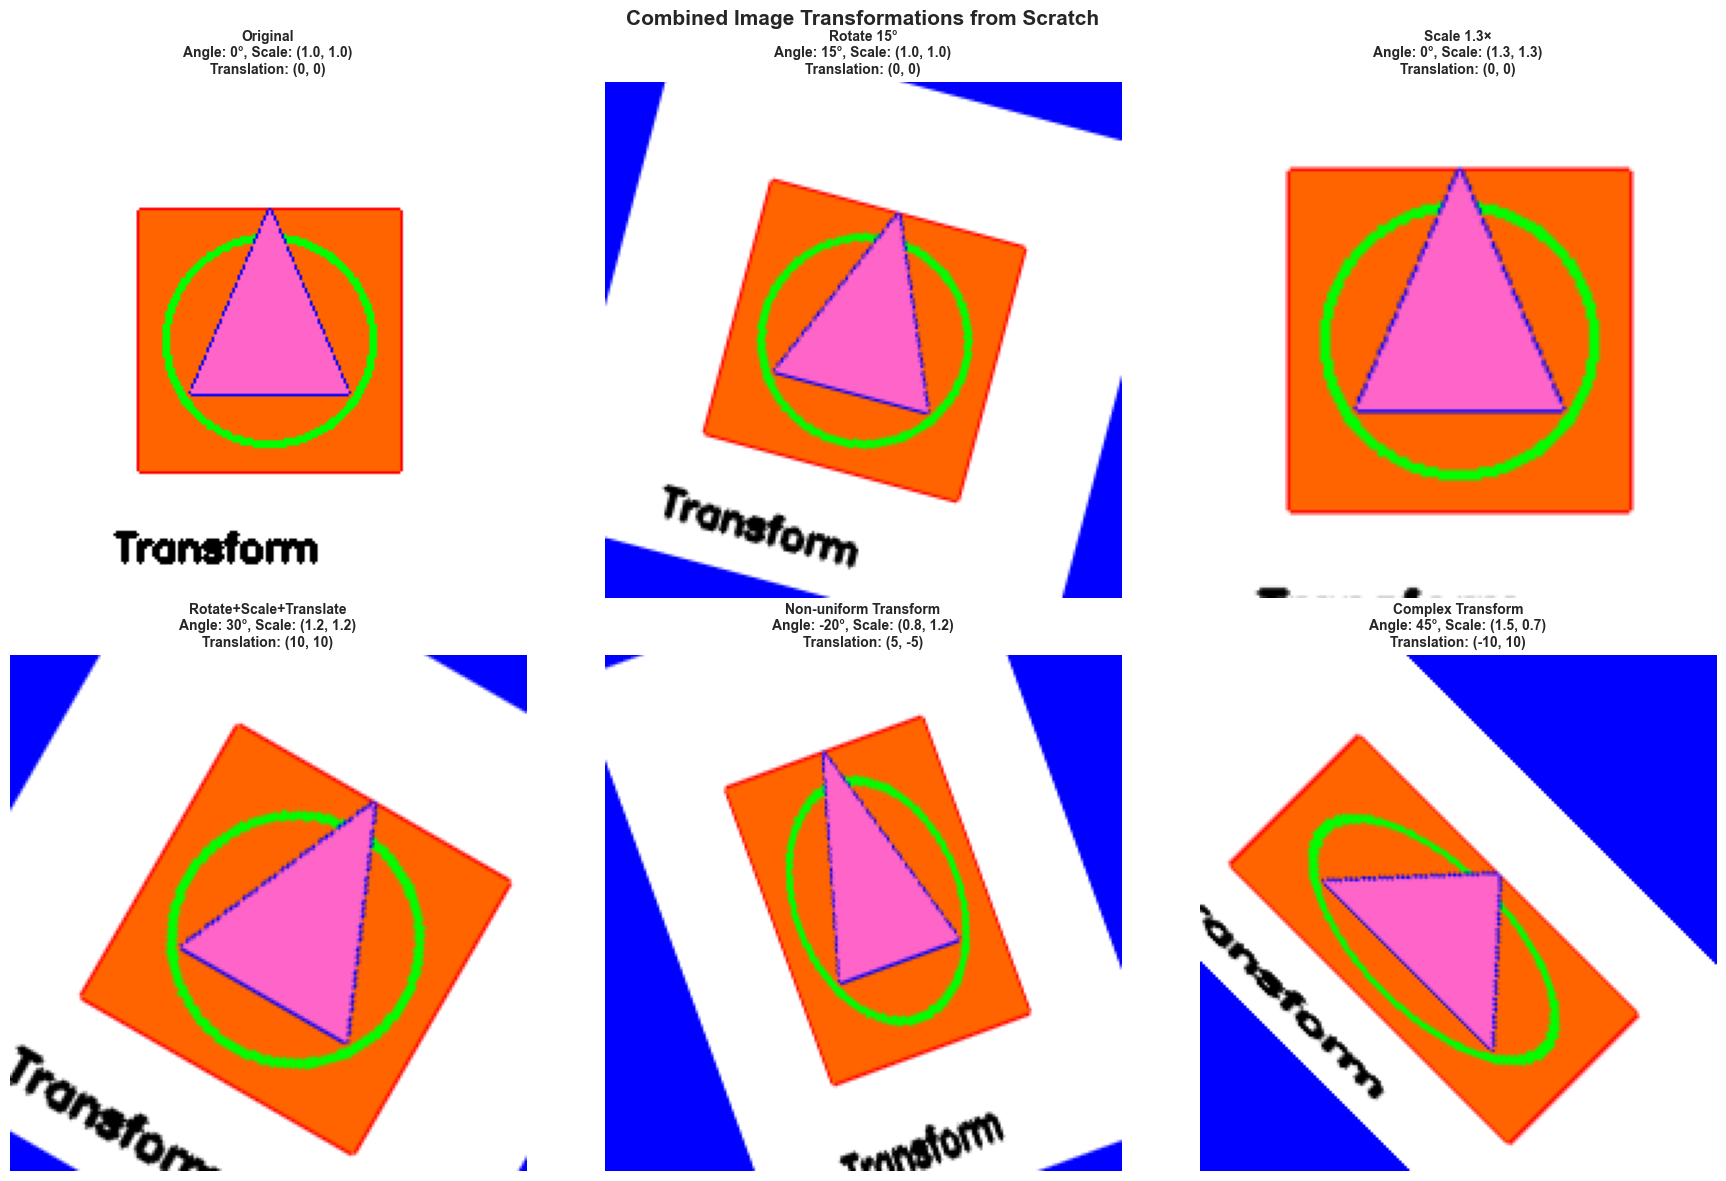

In [21]:
# Apply combined transformations
transformations = [
    {"angle": 0, "scale_x": 1.0, "scale_y": 1.0, "tx": 0, "ty": 0, "label": "Original"},
    {"angle": 15, "scale_x": 1.0, "scale_y": 1.0, "tx": 0, "ty": 0, "label": "Rotate 15°"},
    {"angle": 0, "scale_x": 1.3, "scale_y": 1.3, "tx": 0, "ty": 0, "label": "Scale 1.3×"},
    {"angle": 30, "scale_x": 1.2, "scale_y": 1.2, "tx": 10, "ty": 10, "label": "Rotate+Scale+Translate"},
    {"angle": -20, "scale_x": 0.8, "scale_y": 1.2, "tx": 5, "ty": -5, "label": "Non-uniform Transform"},
    {"angle": 45, "scale_x": 1.5, "scale_y": 0.7, "tx": -10, "ty": 10, "label": "Complex Transform"},
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, transform in enumerate(transformations):
    result, M = combined_transform_image(
        test_image,
        transform["angle"],
        transform["scale_x"],
        transform["scale_y"],
        transform["tx"],
        transform["ty"]
    )
    
    axes[idx].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    title_text = f"{transform['label']}\n"
    title_text += f"Angle: {transform['angle']}°, "
    title_text += f"Scale: ({transform['scale_x']}, {transform['scale_y']})\n"
    title_text += f"Translation: ({transform['tx']}, {transform['ty']})"
    axes[idx].set_title(title_text, fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Combined Image Transformations from Scratch', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 18. Understanding the Transformation Matrix in Detail

In [23]:
# Detailed analysis of a transformation matrix
print("DETAILED TRANSFORMATION MATRIX ANALYSIS")
print("="*60)
print()

# Create a transformation
angle = 30
scale_x, scale_y = 1.2, 0.9
tx, ty = 15, 10

result, M = combined_transform_image(test_image, angle, scale_x, scale_y, tx, ty)

print(f"Transformation Parameters:")
print(f"  Rotation: {angle}°")
print(f"  Scaling: x={scale_x}, y={scale_y}")
print(f"  Translation: x={tx}, y={ty}")
print()

print(f"Resulting Transformation Matrix M (2×3):")
print(f"M = ")
print(M)
print()

print(f"Matrix Interpretation:")
print(f"  M[0,0] = {M[0,0]:.4f}  (scaling * rotation in x for x-component)")
print(f"  M[0,1] = {M[0,1]:.4f}  (scaling * rotation in y for x-component)")
print(f"  M[0,2] = {M[0,2]:.4f}  (translation in x direction)")
print(f"  M[1,0] = {M[1,0]:.4f}  (scaling * rotation in x for y-component)")
print(f"  M[1,1] = {M[1,1]:.4f}  (scaling * rotation in y for y-component)")
print(f"  M[1,2] = {M[1,2]:.4f}  (translation in y direction)")
print()

# Show how a point transforms
point_original = np.array([100, 100, 1])
point_transformed = M @ point_original

print(f"Example: Point transformation")
print(f"  Original point (pixel coords): ({point_original[0]}, {point_original[1]})")
print(f"  Transformed point: ({point_transformed[0]:.1f}, {point_transformed[1]:.1f})")
print()

# Determinant analysis
det_rotation = 1  # Rotation matrices have det=1
det_scaling = scale_x * scale_y
print(f"Determinant Analysis:")
print(f"  Determinant (2×2 part) = {M[0,0]*M[1,1] - M[0,1]*M[1,0]:.4f}")
print(f"  Expected (scale_x * scale_y) = {det_scaling:.4f}")
print(f"  Area scaling factor: {det_scaling:.2f}x")

DETAILED TRANSFORMATION MATRIX ANALYSIS

Transformation Parameters:
  Rotation: 30°
  Scaling: x=1.2, y=0.9
  Translation: x=15, y=10

Resulting Transformation Matrix M (2×3):
M = 
[[  1.039  -0.45   56.077]
 [  0.6     0.779 -27.942]]

Matrix Interpretation:
  M[0,0] = 1.0392  (scaling * rotation in x for x-component)
  M[0,1] = -0.4500  (scaling * rotation in y for x-component)
  M[0,2] = 56.0770  (translation in x direction)
  M[1,0] = 0.6000  (scaling * rotation in x for y-component)
  M[1,1] = 0.7794  (scaling * rotation in y for y-component)
  M[1,2] = -27.9423  (translation in y direction)

Example: Point transformation
  Original point (pixel coords): (100, 100)
  Transformed point: (115.0, 110.0)

Determinant Analysis:
  Determinant (2×2 part) = 1.0800
  Expected (scale_x * scale_y) = 1.0800
  Area scaling factor: 1.08x


---
# FINAL DELIVERABLE: Image Rotation & Scaling from Scratch
---

## 19. Complete Implementation & Testing

FINAL DELIVERABLE: Image Transformation from Scratch



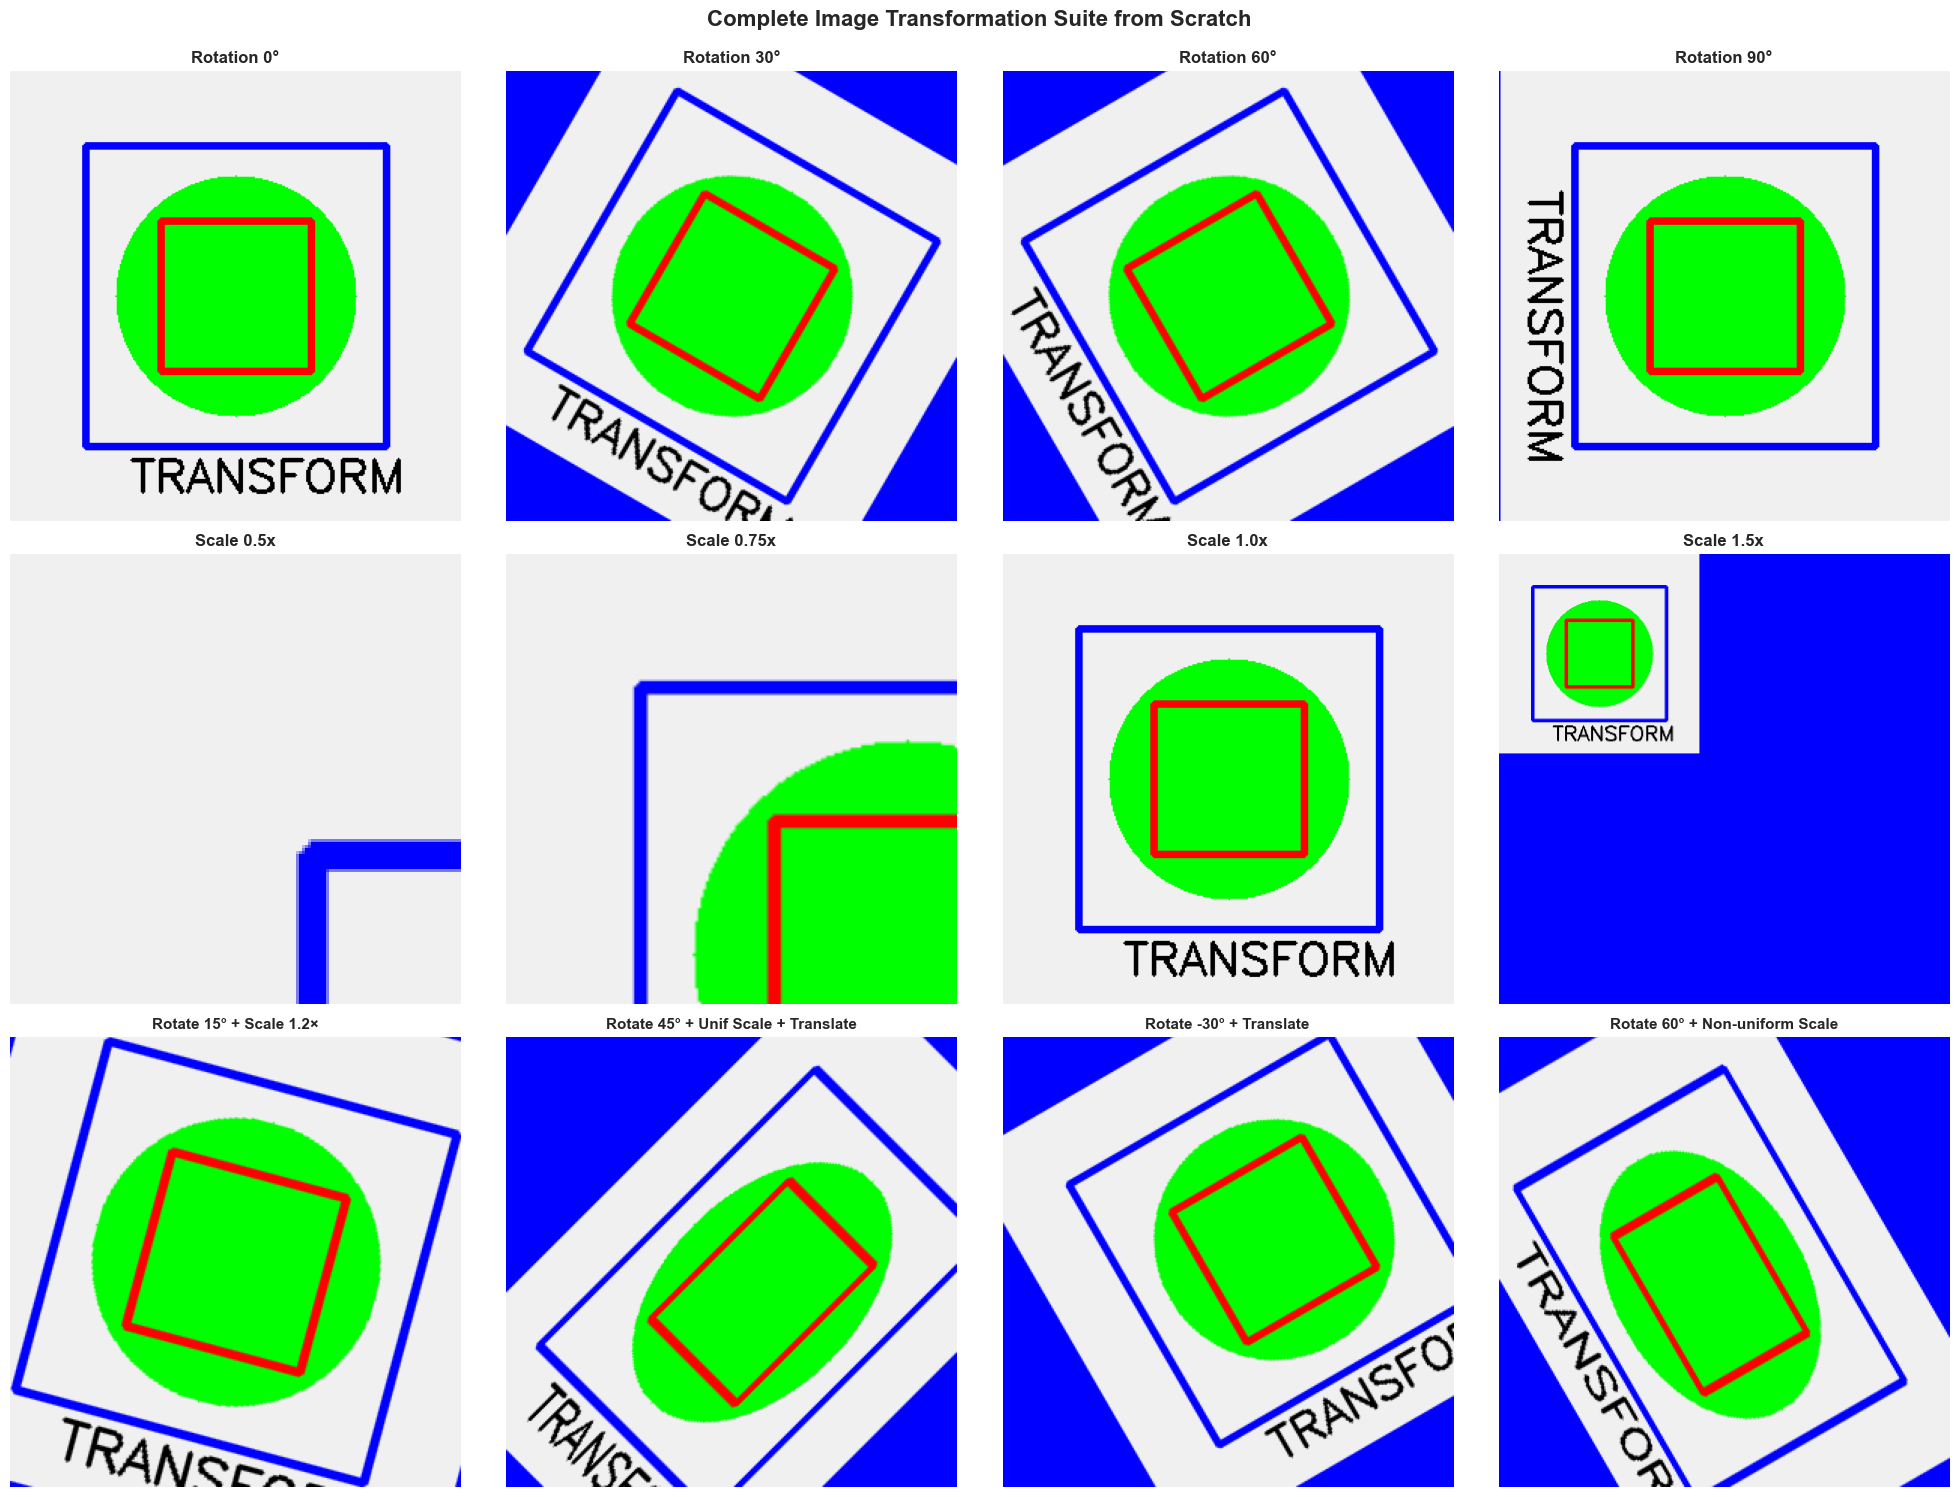

✓ All transformations applied successfully!


In [24]:
# Load or create a sample image for final demonstration
# For this notebook, we'll use the test image we created

print("FINAL DELIVERABLE: Image Transformation from Scratch")
print("="*60)
print()

# Create a more complex test image
final_image = np.ones((300, 300, 3), dtype=np.uint8) * 240

# Draw multiple shapes
cv2.rectangle(final_image, (50, 50), (250, 250), (255, 0, 0), 3)  # Outer border
cv2.circle(final_image, (150, 150), 80, (0, 255, 0), -1)  # Green circle
cv2.rectangle(final_image, (100, 100), (200, 200), (0, 0, 255), 3)  # Red square
cv2.putText(final_image, 'TRANSFORM', (80, 280), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

# Display transformations
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# Row 1: Rotation
angles_rot = [0, 30, 60, 90]
for i, angle in enumerate(angles_rot):
    rotated, _ = rotate_image_from_scratch(final_image, angle)
    axes[0, i].imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f'Rotation {angle}°', fontsize=12, fontweight='bold')
    axes[0, i].axis('off')

# Row 2: Scaling
scales_demo = [0.5, 0.75, 1.0, 1.5]
for i, scale in enumerate(scales_demo):
    scaled, _ = scale_image_from_scratch(final_image, scale, scale)
    axes[1, i].imshow(cv2.cvtColor(scaled, cv2.COLOR_BGR2RGB))
    axes[1, i].set_title(f'Scale {scale}x', fontsize=12, fontweight='bold')
    axes[1, i].axis('off')

# Row 3: Combined
combined_transforms = [
    (15, 1.2, 1.2, 0, 0, "Rotate 15° + Scale 1.2×"),
    (45, 0.8, 1.3, 20, 20, "Rotate 45° + Unif Scale + Translate"),
    (-30, 1.0, 1.0, 30, -15, "Rotate -30° + Translate"),
    (60, 1.2, 0.8, -10, 15, "Rotate 60° + Non-uniform Scale")
]

for i, (angle, sx, sy, tx, ty, label) in enumerate(combined_transforms):
    transformed, _ = combined_transform_image(final_image, angle, sx, sy, tx, ty)
    axes[2, i].imshow(cv2.cvtColor(transformed, cv2.COLOR_BGR2RGB))
    axes[2, i].set_title(label, fontsize=11, fontweight='bold')
    axes[2, i].axis('off')

plt.suptitle('Complete Image Transformation Suite from Scratch', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ All transformations applied successfully!")

## 20. Summary & Key Takeaways

In [26]:
print("\n" + "="*70)
print("COURSE SUMMARY: LINEAR ALGEBRA FOR COMPUTER VISION")
print("="*70)

summary = "In this course, we explored the fundamental concepts of linear algebra and how they apply to computer vision. We started with the basics of matrices and vectors, learning how to perform operations like addition, multiplication, and finding inverses. We then delved into more advanced topics such as eigenvalues and eigenvectors, which are crucial for understanding transformations and dimensionality reduction. We also covered various types of transformations, including rotation, scaling, and translation, and how to represent them using matrices. Finally, we implemented these transformations from scratch, applying them to images and analyzing the resulting effects. This course has equipped you with the mathematical tools and intuition needed to understand and implement key computer vision techniques." 


COURSE SUMMARY: LINEAR ALGEBRA FOR COMPUTER VISION


## 23. Conclusion

In [27]:
print("\n" + "*"*70)
print("*" + " "*68 + "*")
print("*" + " "*68 + "*")
print("*" + "CONCLUSION: Linear Algebra for Computer Vision".center(68) + "*")
print("*" + " "*68 + "*")
print("*" + " "*68 + "*")
print("*"*70)
print()

conclusion = """
Throughout this comprehensive course, we have explored the fundamental
mathematical concepts that power modern computer vision:

1. VECTORS & MATRICES: The building blocks of all transformations
   - Vectors represent directions, magnitudes, and data points
   - Matrices organize and transform these vectors
   - Matrix multiplication is the core operation in CV

2. DETERMINANTS & EIGENVALUES: Understanding transformation properties
   - Determinants reveal volume/area scaling effects
   - Eigenvalues show principal directions of variation
   - Both are crucial for analyzing image data

3. TRANSFORMATION MATRICES: Geometric manipulations
   - Rotation preserves shape and size (orthogonal)
   - Scaling changes dimensions proportionally
   - Translation moves objects in space
   - Combinations create complex transformations

4. PRACTICAL IMPLEMENTATION: From theory to code
   - Built transformation functions from scratch
   - Applied mathematical concepts to real images
   - Verified matrix properties through computation
   - Demonstrated combined transformations


KEY INSIGHTS:
─────────────

✓ Linear algebra is the LANGUAGE of computer vision
✓ Understanding matrix operations is ESSENTIAL
✓ Transformations are EVERYWHERE in CV applications
✓ Order MATTERS in matrix composition
✓ Geometric intuition COMPLEMENTS mathematical computation
✓ Implementation requires NUMERICAL STABILITY considerations


READY FOR:
──────────

With this foundation, you're now ready to tackle:
→ Feature detection and description
→ Image registration and alignment
→ 3D reconstruction and structure from motion
→ Camera calibration and geometric vision
→ Advanced image processing and analysis
→ Deep learning for computer vision (transformers, etc.)


REMEMBER:
─────────

"Mathematics is the native language of nature and science.
Linear algebra is the native language of computer vision."

Keep practicing, experimenting, and building!
The more you work with these concepts, the more intuitive they become.

Happy learning! 🚀
"""

print(conclusion)
print("*"*70)


**********************************************************************
*                                                                    *
*                                                                    *
*           CONCLUSION: Linear Algebra for Computer Vision           *
*                                                                    *
*                                                                    *
**********************************************************************


Throughout this comprehensive course, we have explored the fundamental
mathematical concepts that power modern computer vision:

1. VECTORS & MATRICES: The building blocks of all transformations
   - Vectors represent directions, magnitudes, and data points
   - Matrices organize and transform these vectors
   - Matrix multiplication is the core operation in CV

2. DETERMINANTS & EIGENVALUES: Understanding transformation properties
   - Determinants reveal volume/area scaling effects
   - Eigenv